<a href="https://colab.research.google.com/github/Vivekshrotriya1/Capgemini-Training/blob/main/Capstone_Project_3_%26_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Capstone Project 3
Smart Marketing Prediction System (ML Pipeline Project)
#Scenario
A fast-growing e-commerce company called ShopEasy is struggling with inefficient marketing campaigns.

Every day thousands of users visit their website. The marketing team spends a large amount of money showing ads, discounts, and promotional emails, but they don't know which customers are actually likely to buy something.

Currently:

Many customers browse but never purchase

Marketing money is wasted on the wrong users

The company wants to predict purchase probability

The data science team has been asked to build a machine learning system that predicts whether a customer will purchase a product during a session.

If the system predicts high probability of purchase, the system will:

show personalized product recommendations

offer targeted discounts

prioritize marketing campaigns

If the system predicts low probability, the company will avoid spending marketing resources.

However, the dataset contains both numerical and categorical features, so the data science team must design a complete ML pipeline.



#Business Objective
Build a machine learning model that predicts whether a user will purchase (1) or not purchase (0) during a website session.

The model must be implemented using scikit-learn pipelines, including:

Encoding techniques

Feature preprocessing

Model training

Model selection

Hyperparameter tuning

#Capstone Project 4
#Project Scenario
Smart Traffic Sign Recognition System
Scenario
A city is building a Smart Traffic Monitoring System to improve road safety.

Every intersection in the city will have cameras that detect traffic signs automatically.

The system must recognize different road signs such as:

Stop sign

Speed limit sign

Pedestrian crossing sign

The system will be used in autonomous vehicles and traffic monitoring cameras.

However, the engineers discovered two challenges:

- First, the system must understand basic classification logic (learning from features).
- Second, it must classify images of traffic signs captured by cameras.

To solve this, the engineering team decided to build the system in two stages.

#Stage 1
Learning Basic Neural Networks (Perceptron)
Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.



CAPSTONE PROJECT 3
Smart Marketing Prediction


Saving DatasetCapstoneProject3.xlsx to DatasetCapstoneProject3 (1).xlsx

Dataset Head:
   CustomerID  Age  Gender   Device  Traffic_Source  Time_on_Website  \
0           1   23    Male   Mobile    Social Media                5   
1           2   35  Female  Desktop   Search Engine               12   
2           3   29    Male   Tablet    Social Media                8   
3           4   41  Female   Mobile  Email Campaign               15   
4           5   22  Female  Desktop          Direct                4   

   Pages_Visited  Ad_Clicks  Previous_Purchases  Purchased  
0              3          1                   0          0  
1              8          3                   2          1  
2              5          2                   1          0  
3             10          4                   3          1  
4              2          0                   0          0  


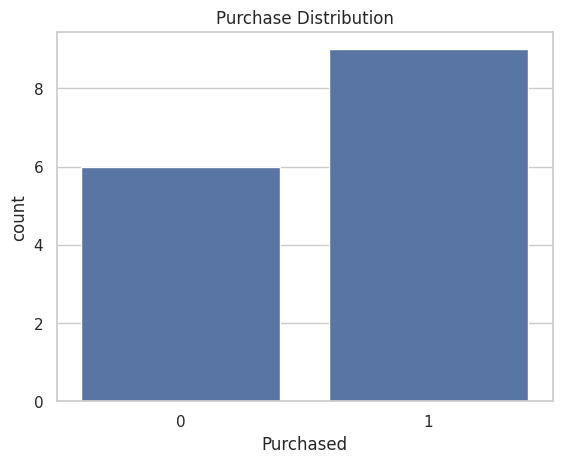

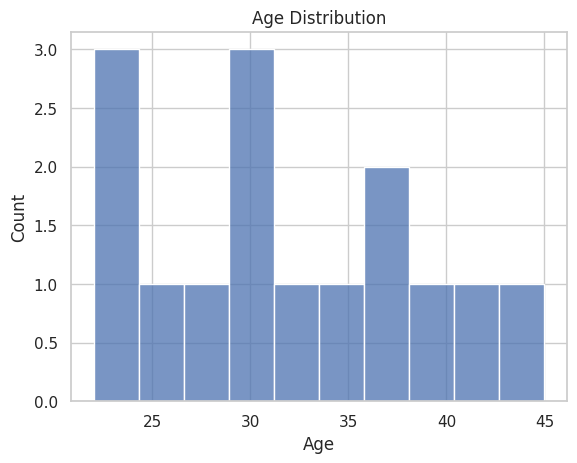

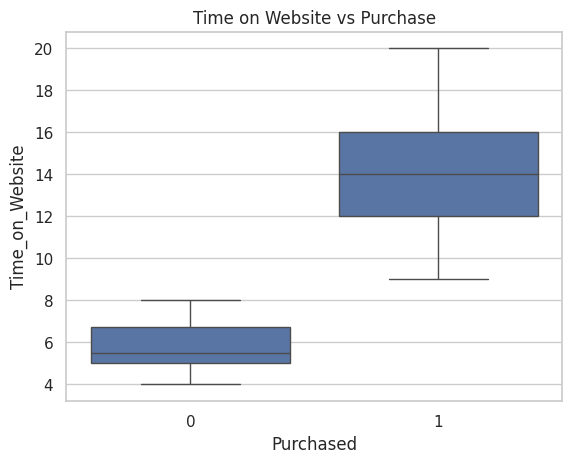

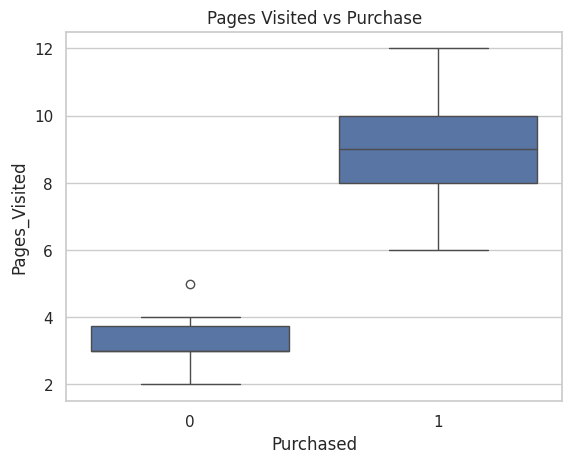

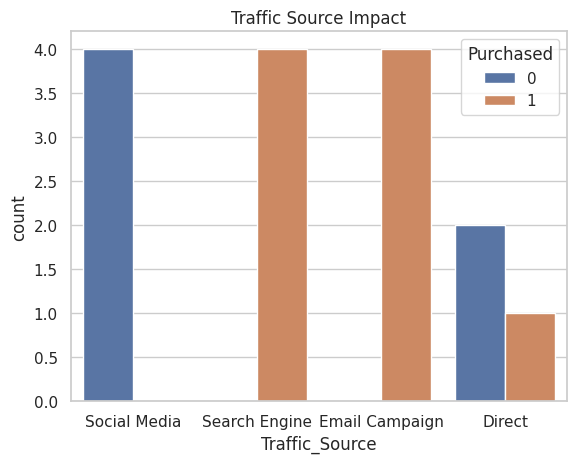

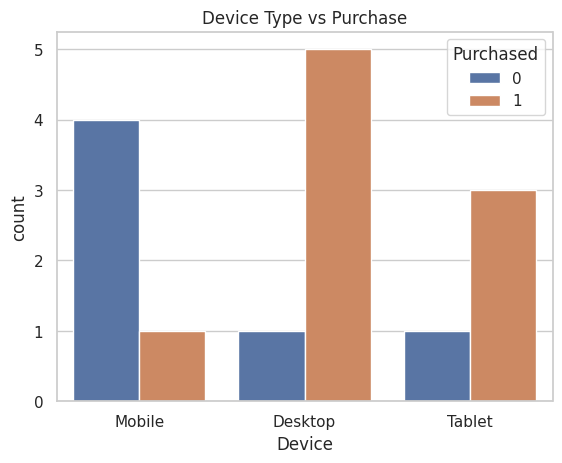

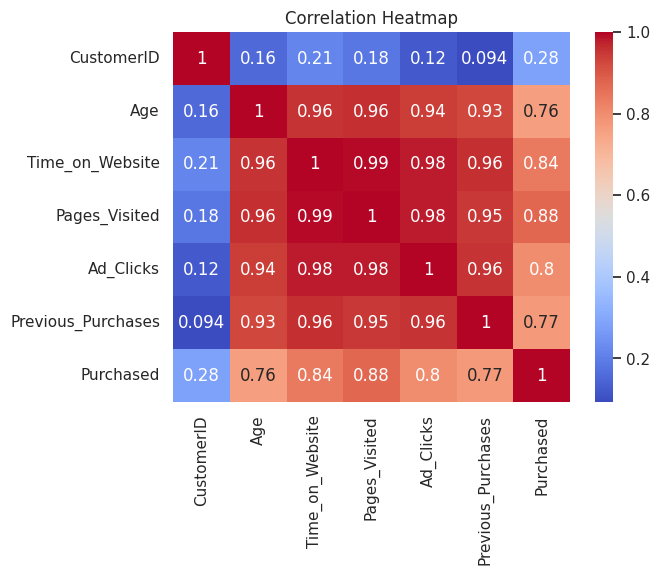

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



Best Parameters: {'model__max_depth': 5, 'model__n_estimators': 50}

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



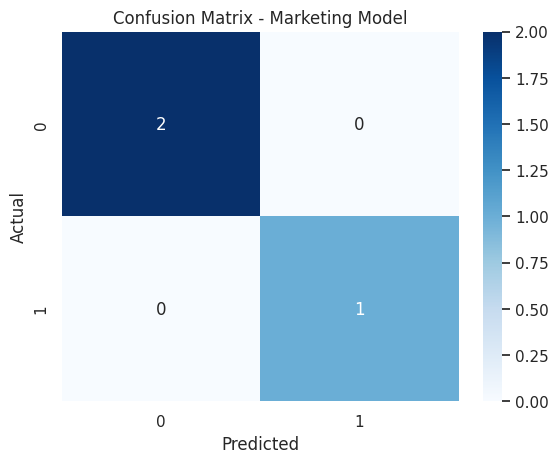

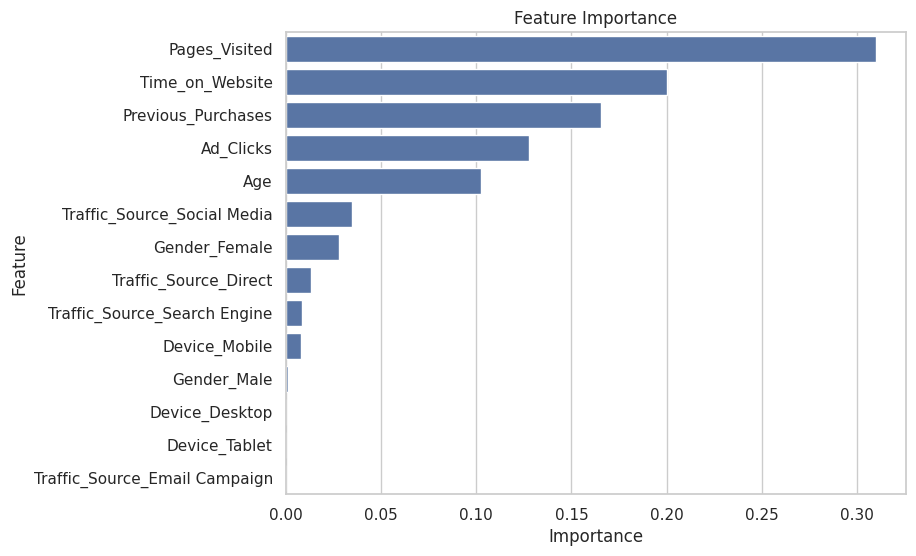

CAPSTONE PROJECT 4
Traffic Sign Perceptron


Saving DatasetCapstoneProject4.csv to DatasetCapstoneProject4.csv

Dataset Head:
   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0           5   
4        5                 0.88               0             1           8   

   Stop_Sign  
0          1  
1          0  
2          1  
3          0  
4          1  


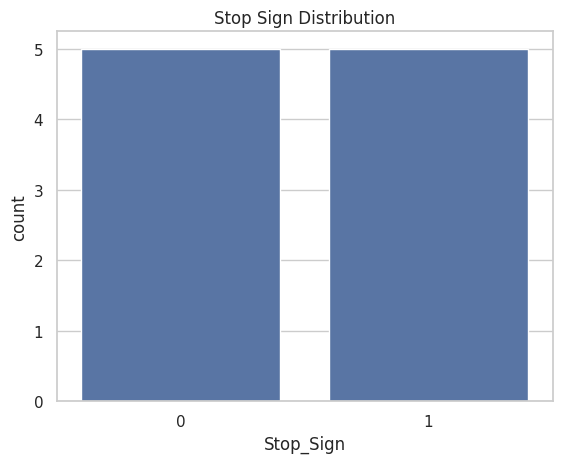

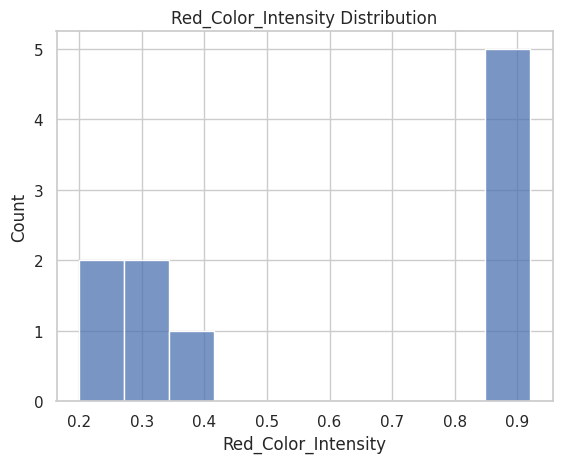

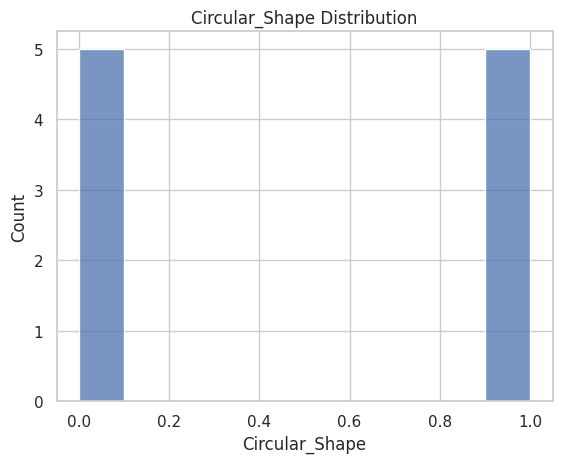

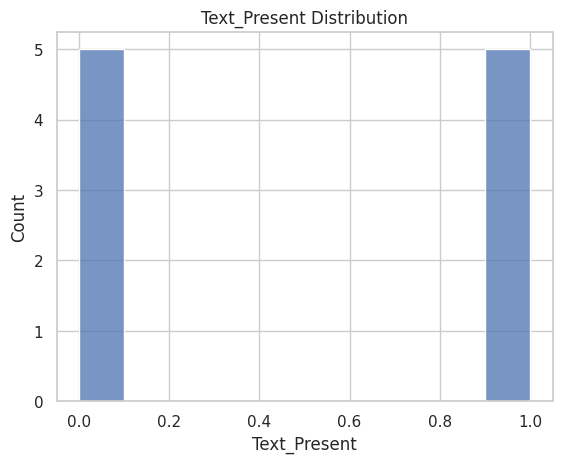

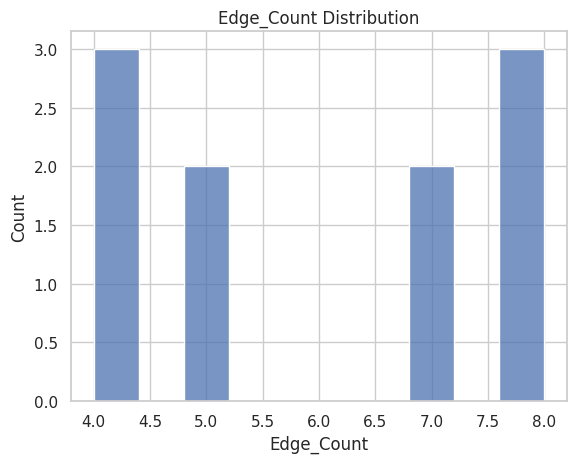

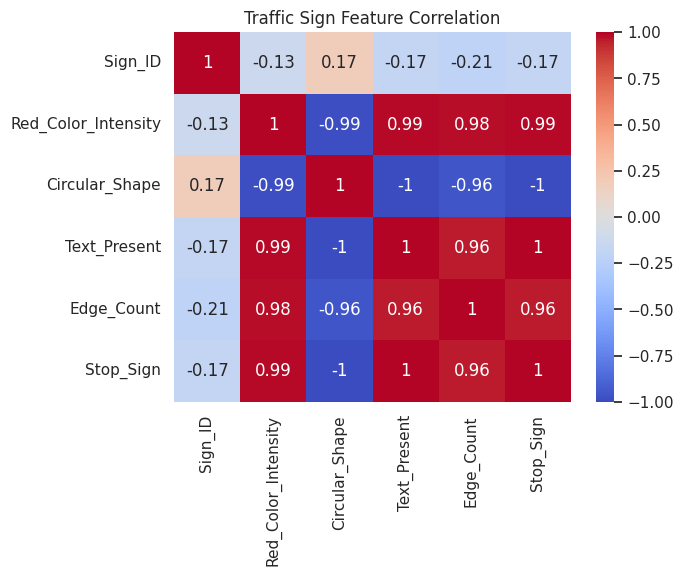


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



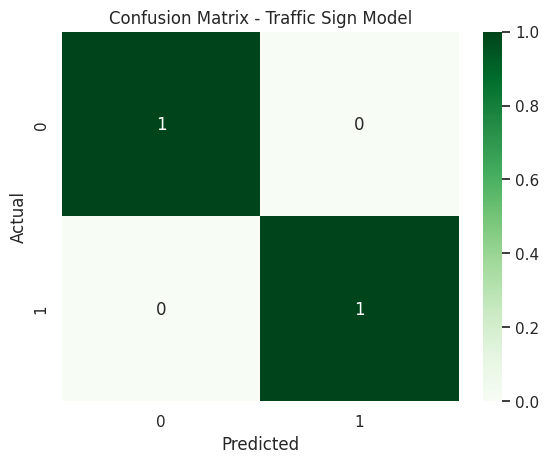


Detected: NOT STOP SIGN

All Capstone Projects Completed Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


In [3]:

# CAPSTONE PROJECT 3 + 4


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import Perceptron

sns.set(style="whitegrid")


# CAPSTONE PROJECT 3
# Smart Marketing Prediction System



print("CAPSTONE PROJECT 3")
print("Smart Marketing Prediction")

# Load dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_excel("DatasetCapstoneProject3.xlsx")


print("\nDataset Head:")
print(df.head())



# Purchase Distribution
plt.figure()
sns.countplot(x="Purchased", data=df)
plt.title("Purchase Distribution")
plt.show()

# Age Distribution
plt.figure()
sns.histplot(df["Age"], bins=10)
plt.title("Age Distribution")
plt.show()

# Time on Website vs Purchase
plt.figure()
sns.boxplot(x="Purchased", y="Time_on_Website", data=df)
plt.title("Time on Website vs Purchase")
plt.show()

# Pages Visited vs Purchase
plt.figure()
sns.boxplot(x="Purchased", y="Pages_Visited", data=df)
plt.title("Pages Visited vs Purchase")
plt.show()

# Traffic Source vs Purchase
plt.figure()
sns.countplot(x="Traffic_Source", hue="Purchased", data=df)
plt.title("Traffic Source Impact")
plt.show()

# Device vs Purchase
plt.figure()
sns.countplot(x="Device", hue="Purchased", data=df)
plt.title("Device Type vs Purchase")
plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



X = df.drop(["CustomerID", "Purchased"], axis=1)
y = df["Purchased"]

categorical_cols = ["Gender", "Device", "Traffic_Source"]
numeric_cols = [
    "Age",
    "Time_on_Website",
    "Pages_Visited",
    "Ad_Clicks",
    "Previous_Purchases"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(), categorical_cols)
    ]
)

model = RandomForestClassifier()

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

param_grid = {
    "model__n_estimators": [50,100],
    "model__max_depth": [5,10]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# Predictions
y_pred = grid.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")
plt.title("Confusion Matrix - Marketing Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
rf = grid.best_estimator_.named_steps["model"]

feature_names = numeric_cols + list(
    grid.best_estimator_
    .named_steps["preprocessing"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_cols)
)

importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()


# CAPSTONE PROJECT 4
# Traffic Sign Recognition



print("CAPSTONE PROJECT 4")
print("Traffic Sign Perceptron")

from google.colab import files
uploaded = files.upload()
df2 = pd.read_csv("DatasetCapstoneProject4.csv")

print("\nDataset Head:")
print(df2.head())


# DATA VISUALIZATION


# Stop Sign Distribution
plt.figure()
sns.countplot(x="Stop_Sign", data=df2)
plt.title("Stop Sign Distribution")
plt.show()

# Feature Distributions
features = ["Red_Color_Intensity", "Circular_Shape", "Text_Present", "Edge_Count"]

for f in features:
    plt.figure()
    sns.histplot(df2[f], bins=10)
    plt.title(f + " Distribution")
    plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df2.corr(), annot=True, cmap="coolwarm")
plt.title("Traffic Sign Feature Correlation")
plt.show()


# MODEL TRAINING


X2 = df2.drop(["Sign_ID", "Stop_Sign"], axis=1)
y2 = df2["Stop_Sign"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

perceptron = Perceptron(max_iter=1000, eta0=0.1)

perceptron.fit(X_train2, y_train2)

y_pred2 = perceptron.predict(X_test2)

print("\nAccuracy:", accuracy_score(y_test2, y_pred2))

print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))

# Confusion Matrix Visualization
plt.figure()
sns.heatmap(confusion_matrix(y_test2, y_pred2), annot=True, cmap="Greens")
plt.title("Confusion Matrix - Traffic Sign Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Sample Prediction


new_sign = np.array([[0.9, 1, 1, 8]])

prediction = perceptron.predict(new_sign)

if prediction == 1:
    print("\nDetected: STOP SIGN")
else:
    print("\nDetected: NOT STOP SIGN")

print("\nAll Capstone Projects Completed Successfully")